# Predição de Intenção de Compra em E-commerce

## Objetivo

Desenvolver modelos de Machine Learning capazes de prever a propensão de compra online de clientes a partir de características demográficas e comportamentais.

O projeto busca identificar padrões de consumo que possam auxiliar equipes de marketing na segmentação de campanhas e na identificação de clientes com maior potencial de conversão.

# 1. Entendimento dos Dados


In [1]:
# Carregando a base
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from datetime import datetime
import os

os.makedirs("images", exist_ok=True)

os.makedirs("../data", exist_ok=True)

df = pd.read_csv(
    "../data/marketing_campaign.csv",
    sep=";"
)

df.head()

df["WebPurchases"].value_counts()

df_pbi = df.copy()

current_year = datetime.now().year

df_pbi["Age"] = current_year - df_pbi["Year_Birth"]

df_pbi["Children"] = df_pbi["Kidhome"]

df_pbi["TotalSpent"] = (
    df_pbi["MntWines"]
    + df_pbi["MntFruits"]
    + df_pbi["MntMeatProducts"]
    + df_pbi["MntFishProducts"]
    + df_pbi["MntSweetProducts"]
    + df_pbi["MntGoldProds"]
)

df_pbi["Income"] = df_pbi["Income"].fillna(
    df_pbi["Income"].median()
)

df_pbi["CustomerType"] = df_pbi["WebPurchases"].map({
    1: "Comprador",
    0: "Não Comprador"
})

df_pbi.to_csv(
    "../data/marketing_campaign_tratado.csv",
    index=False
)

A variável alvo do projeto é **WebPurchases**, que indica se o cliente realizou compra pelo canal online.

O objetivo da análise é identificar características associadas à maior propensão de compra.

# 2. Análise Exploratória dos Dados

## Hipótese 1 — Clientes com maior renda compram mais online?

In [2]:
df.groupby("WebPurchases")["Income"].mean()

WebPurchases
0    41065.455373
1    63229.015206
Name: Income, dtype: float64

## Hipótese 2 — Clientes que visitam mais o site compram mais?

In [3]:
df.groupby("WebPurchases")["NumWebVisitsMonth"].mean()

WebPurchases
0    5.710432
1    4.928191
Name: NumWebVisitsMonth, dtype: float64

## Hipótese 3 — Compras em loja física influenciam compras online?

In [4]:
df.groupby("WebPurchases")["NumStorePurchases"].mean()

WebPurchases
0    4.000899
1    7.554078
Name: NumStorePurchases, dtype: float64

## Hipótese 4 — Clientes que gastam mais possuem maior propensão à compra?

In [5]:
df["TotalSpent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df.groupby("WebPurchases")["TotalSpent"].mean()

WebPurchases
0    263.019784
1    943.714539
Name: TotalSpent, dtype: float64

### Insight

Os resultados indicam que clientes com maior histórico de gastos apresentam maior propensão à compra online.

Isso sugere que consumidores com elevado valor acumulado de compras podem representar um público estratégico para campanhas digitais e programas de fidelização.

## Hipótese 5 — Produtos favoritos influenciam a compra online?

In [6]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df.groupby("WebPurchases")[product_cols].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
WebPurchases,,,,,,
0,117.356115,12.331835,79.394784,18.893885,11.696942,23.346223
1,487.868794,40.074468,253.263298,55.892730,42.210993,64.404255


## Hipótese 6 — Reclamações reduzem a intenção de compra?

In [7]:
df.groupby("WebPurchases")["Complain"].mean()

WebPurchases
0    0.012590
1    0.006206
Name: Complain, dtype: float64

## Hipótese 7 — A recência influencia a compra?

In [8]:
df.groupby("WebPurchases")["Recency"].mean()

WebPurchases
0    49.099820
1    49.118794
Name: Recency, dtype: float64

## Principais Insights da EDA

A análise exploratória revelou alguns padrões importantes:

- Clientes com maior renda apresentam maior propensão à compra online.
- Clientes que compram online visitam menos o site, indicando comportamento mais objetivo.
- Clientes que realizam compras em lojas físicas também apresentam maior tendência de compra online.
- O histórico de gastos mostrou forte associação com a intenção de compra.
- Clientes que realizaram reclamações apresentaram menor propensão à compra.

# 3. Engenharia de Features

Foram criadas novas variáveis com o objetivo de representar melhor o comportamento dos clientes.

As variáveis criadas foram:

- Age: idade do cliente.
- Children: quantidade de crianças em casa.
- TotalSpent: gasto total acumulado.

In [9]:
current_year = datetime.now().year

# idade
df["Age"] = current_year - df["Year_Birth"]

# filhos
df["Children"] = df["Kidhome"]

# gasto total
df["TotalSpent"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)
df[["Age", "Children", "TotalSpent"]].describe()

,Age,Children,TotalSpent
count,2240.000000,2240.000000,2240.000000
mean,57.194196,0.444196,605.798214
std,11.984069,0.538398,602.249288
min,30.000000,0.000000,5.000000
25%,49.000000,0.000000,68.750000
50%,56.000000,0.000000,396.000000
75%,67.000000,1.000000,1045.500000
max,133.000000,2.000000,2525.000000


In [10]:
# Cópia para Power BI
df_pbi = df.copy()

# Features criadas
current_year = datetime.now().year

df_pbi["Age"] = current_year - df_pbi["Year_Birth"]

df_pbi["Children"] = df_pbi["Kidhome"]

df_pbi["TotalSpent"] = (
    df_pbi["MntWines"]
    + df_pbi["MntFruits"]
    + df_pbi["MntMeatProducts"]
    + df_pbi["MntFishProducts"]
    + df_pbi["MntSweetProducts"]
    + df_pbi["MntGoldProds"]
)

# Tratamento de Income
df_pbi["Income"] = df_pbi["Income"].fillna(
    df_pbi["Income"].median()
)

df_pbi.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,TotalSpent,Age,Children
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1,1617,69,0
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0,27,72,1
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1,776,61,0
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0,53,42,1
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1,422,45,1


# 4. Análise das Novas Features

As novas variáveis criadas foram analisadas individualmente para verificar sua relação com a variável alvo.

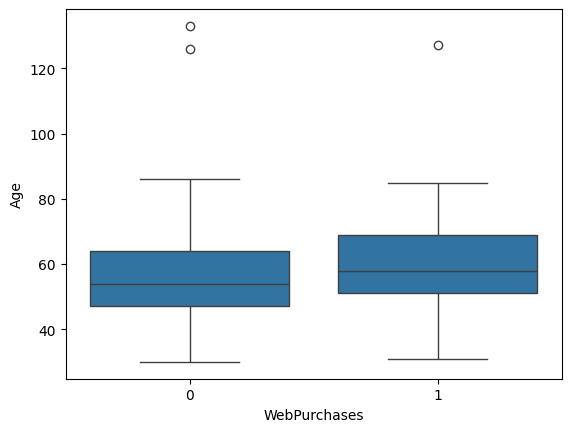

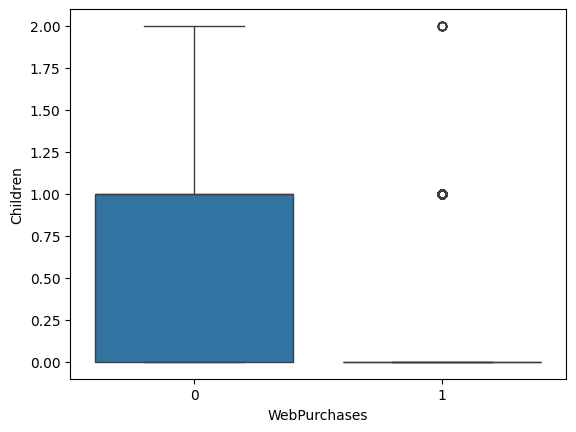

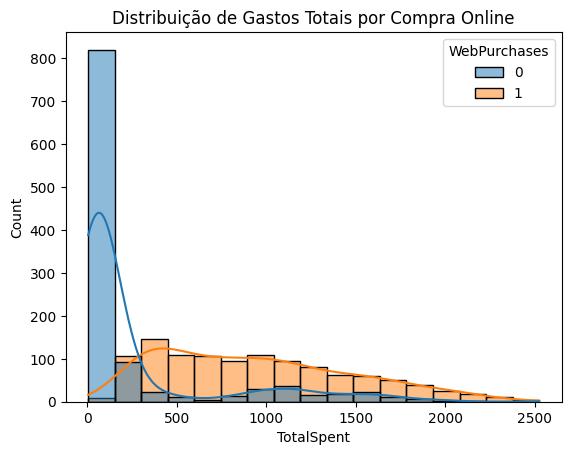

In [11]:
sns.boxplot(
    x='WebPurchases',
    y='Age',
    data=df
)
plt.show()

sns.boxplot(
    x='WebPurchases',
    y='Children',
    data=df
)
plt.show()

sns.histplot(
    data=df,
    x="TotalSpent",
    hue="WebPurchases",
    kde=True
)

plt.title("Distribuição de Gastos Totais por Compra Online")

plt.savefig(
    "images/total_spent_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# 5. Preparação dos Dados

Nesta etapa foram realizados:

- tratamento de valores ausentes;
- separação entre variáveis preditoras e variável alvo;
- transformação das variáveis categóricas;
- divisão entre conjuntos de treino e teste.

In [12]:
# Variável alvo
y = df["WebPurchases"]

# Variáveis preditoras
X = df.drop(
    columns=["WebPurchases"],
    errors="ignore"
)

# Encoding das variáveis categóricas
X = pd.get_dummies(
    X,
    columns=["Education", "Marital_Status"],
    drop_first=True
)

# Tratamento de valores ausentes
X["Income"] = X["Income"].fillna(X["Income"].median())

# Separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Neste projeto foram desenvolvidos modelos de Machine Learning para prever a intenção de compra online de clientes.

Após análise exploratória e engenharia de atributos, foram avaliados os modelos Regressão Logística e Random Forest.

O Random Forest apresentou o melhor desempenho, alcançando aproximadamente 91% de acurácia e F1-score de 0.91.

As variáveis mais relevantes para a previsão foram TotalSpent, MntWines, MntMeatProducts, NumStorePurchases e Income.

# 6. Modelagem

Foram avaliados dois modelos de classificação:

- Regressão Logística
- Random Forest

## 6.1 Regressão Logística

Utilizada como modelo baseline devido à sua simplicidade e interpretabilidade.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       334
           1       0.86      0.84      0.85       338

    accuracy                           0.85       672
   macro avg       0.85      0.85      0.85       672
weighted avg       0.85      0.85      0.85       672



## 6.2 Random Forest

Modelo baseado em árvores de decisão utilizado para capturar relações mais complexas entre as variáveis.

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(
    y_test,
    pred_rf
))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       334
           1       0.88      0.95      0.91       338

    accuracy                           0.91       672
   macro avg       0.91      0.91      0.91       672
weighted avg       0.91      0.91      0.91       672



# 7. Avaliação dos Modelos

## 7.1 Comparação dos Modelos

| Modelo | Accuracy | F1-score |
|---|---:|---:|
| Regressão Logística | 0.85 | 0.85 |
| Random Forest | 0.91 | 0.91 |


## 7.2 Matriz de Confusão

A matriz de confusão permite avaliar de forma detalhada os acertos e erros realizados pelo modelo Random Forest na classificação dos clientes.

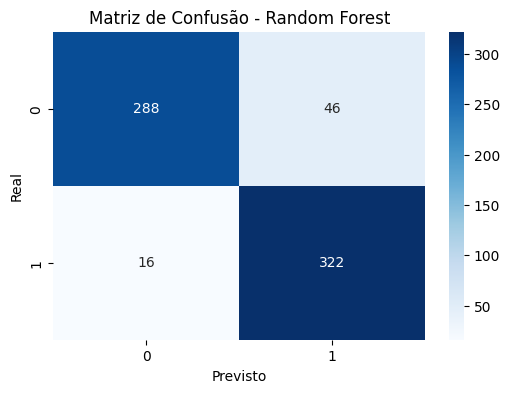

In [15]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.savefig(
    "images/confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### 7.3 Considerações Finais

O Random Forest apresentou o melhor desempenho entre os modelos avaliados, alcançando aproximadamente 91% de acurácia e F1-score de 0.91.

A matriz de confusão confirma a capacidade do modelo de identificar corretamente clientes compradores e não compradores, justificando sua escolha como modelo final para o projeto.

# 8. Importância das Variáveis

Após a seleção do melhor modelo (Random Forest), foi realizada a análise da importância das variáveis para compreender quais características mais influenciam a previsão da intenção de compra online.

A importância das variáveis representa a contribuição de cada atributo para as decisões tomadas pelo modelo durante o processo de classificação.

Os resultados indicam que o histórico de gastos dos clientes é o principal fator associado à propensão de compra. Além disso, categorias específicas de produtos, como vinhos e carnes, também apresentaram elevada relevância para a previsão.

Essa análise permite identificar quais características possuem maior impacto no comportamento de compra dos clientes e pode auxiliar na definição de estratégias de marketing mais direcionadas.

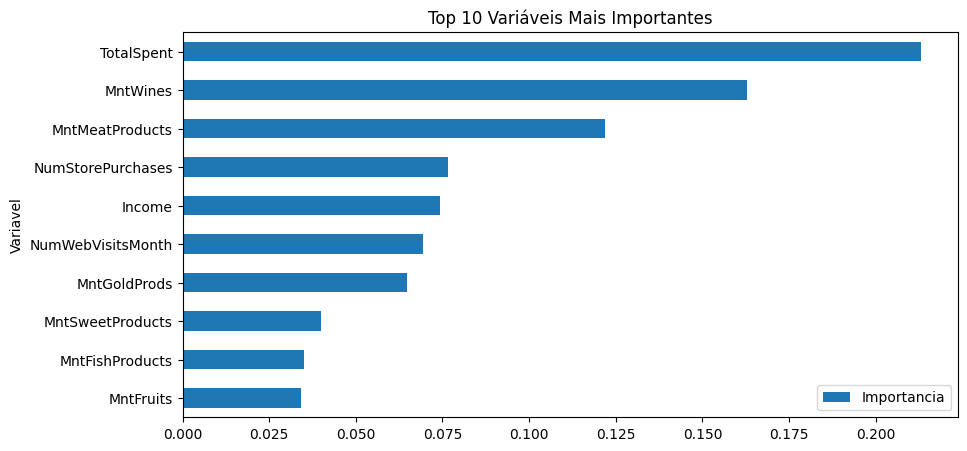

In [16]:
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf.feature_importances_
})

top10 = importancias.sort_values(
    by="Importancia",
    ascending=True
).tail(10)

top10.plot(
    kind="barh",
    x="Variavel",
    y="Importancia",
    figsize=(10,5)
)

plt.savefig(
    "images/feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.title("Top 10 Variáveis Mais Importantes")
plt.show()

## Interpretação dos Resultados

As variáveis mais relevantes identificadas pelo modelo foram:

- TotalSpent
- MntWines
- MntMeatProducts
- NumStorePurchases
- Income

Esses resultados sugerem que o comportamento histórico de consumo é mais importante para prever compras futuras do que características demográficas isoladas.

Em especial, o gasto total acumulado (TotalSpent) destacou-se como o principal indicador de propensão à compra, reforçando os insights observados durante a análise exploratória dos dados.

# 9. Conclusões

O objetivo deste projeto foi prever a intenção de compra online dos clientes a partir de características demográficas e comportamentais.

Durante a análise exploratória foi observado que clientes com maior renda, maior histórico de gastos e menor número de crianças em casa apresentam maior propensão à compra online.

Foram avaliados dois modelos de classificação: Regressão Logística e Random Forest.

O Random Forest apresentou o melhor desempenho, alcançando aproximadamente 91% de acurácia e F1-score de 0.91.

As variáveis mais relevantes para a previsão foram TotalSpent, MntWines, MntMeatProducts, NumStorePurchases e Income.

Dessa forma, conclui-se que o Random Forest é o modelo mais adequado para apoiar estratégias de marketing e segmentação de clientes neste conjunto de dados.